In [1]:
import tempfile
import os
import numpy as np
from process_data import process_data
from prepare_data_for_training import prepare_data
from create_model import create_model
from optimize_model import optimize_and_convert_model,get_gzipped_model_size
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt


ModuleNotFoundError: No module named 'tf_keras'

In [ ]:
data_directory = 'RowData'
wave_and_idle_data = process_data(row_data_dir=data_directory, mode='csv')


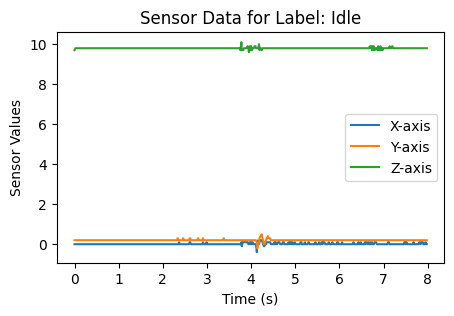

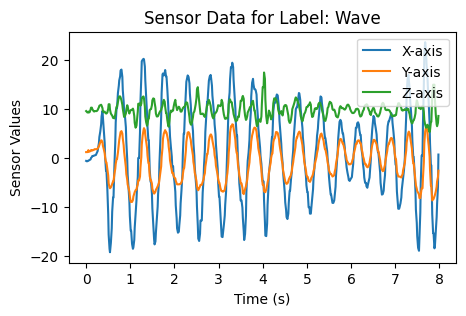

In [ ]:
# plot T second of data for eac label, there is a time column so X axis is time, Y axis is the value of the sensors
T = 5  # seconds
for label in wave_and_idle_data['label'].unique():
    subset = wave_and_idle_data[wave_and_idle_data['label'] == label]
    time = subset['time'][:T*100]  # Assuming data is sampled at 100 Hz
    plt.figure(figsize=(5, 3))
    plt.plot(time, subset['x'][:T*100], label='X-axis')
    plt.plot(time, subset['y'][:T*100], label='Y-axis')
    plt.plot(time, subset['z'][:T*100], label='Z-axis')
    plt.title(f'Sensor Data for Label: {label}')
    plt.xlabel('Time (s)')
    plt.ylabel('Sensor Values')
    plt.legend()
    plt.show()


In [ ]:
X_train, X_test, y_train, y_test = prepare_data(data_directory, window_size_s=1.0, split_ratio=80)
print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")

Requested window: 1.0s. Using 50 timesteps, creating windows of ~1.00s and =actual_window_s.
Labels encoded: {np.str_('Idle'): np.int64(0), np.str_('Wave'): np.int64(1)}
X_train shape: (478, 50, 3), y_train shape: (478,)


In [ ]:
my_model = create_model(input_shape=X_train.shape[1:], num_classes=2)
my_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 48, 8)          │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 24, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 192)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │         3,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,202 (12.51 KB)

 Trainable params: 3,202 (12.51 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6130 - loss: 1.7612 - val_accuracy: 0.9083 - val_loss: 0.4172
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9351 - loss: 0.2818 - val_accuracy: 0.9750 - val_loss: 0.1019
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9686 - loss: 0.1260 - val_accuracy: 0.9917 - val_loss: 0.0494
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9791 - loss: 0.0755 - val_accuracy: 0.9917 - val_loss: 0.0299
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9874 - loss: 0.0492 - val_accuracy: 1.0000 - val_loss: 0.0203
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9916 - loss: 0.0347 - val_accuracy: 1.0000 - val_loss: 0.0120
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9916 - loss: 0.0242 - val_accuracy: 1.0000 - val_loss: 0.0095
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9916 - loss: 0.0172 - val_accuracy: 1.0000 - val_loss

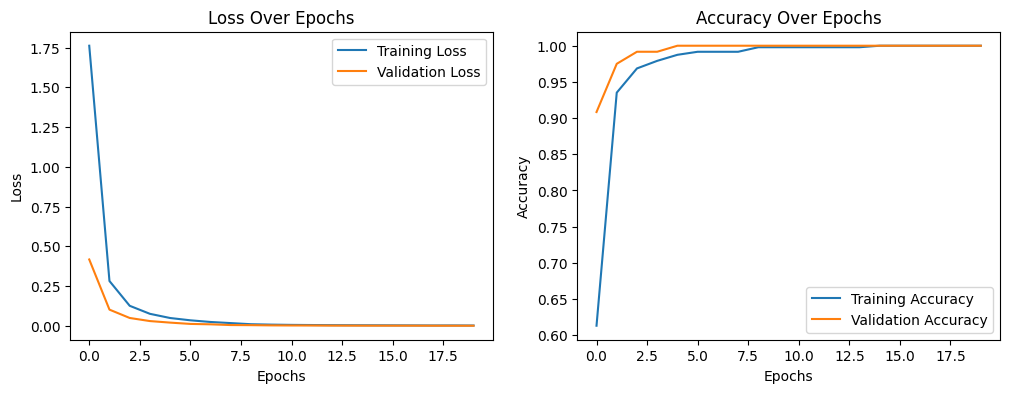

In [ ]:
# fit the model
history = my_model.fit(X_train, y_train, epochs=20, validation_data=(X_test, y_test))
# plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [ ]:
# --- Define a directory to save our models ---
output_dir = 'models'
os.makedirs(output_dir, exist_ok=True) # Create the directory if it doesn't exist

# Save the base model to compare size
base_model_file = os.path.join(output_dir, 'my_model.h5')
my_model.save(base_model_file, include_optimizer=False)
print(f"Base model saved to: {base_model_file}")
print(f"Base model size: {get_gzipped_model_size(base_model_file):.2f} KB")

# --- Optimization ---
print("\n--- Optimizing Model ---")
tflite_model_quant = optimize_and_convert_model(my_model, X_train, y_train)
# --- Save and Compare ---
tflite_model_path = os.path.join(output_dir, 'magic_wand_model.tflite')
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model_quant)
    
print(f"Optimized (quantized) TFLite model size: {get_gzipped_model_size(tflite_model_path):.2f} KB")
print(f"TFLite model saved to: {tflite_model_path}")